# DỰ BÁO DOANH THU THEO CHUỖI THỜI GIAN — Linear Regression & SVR From Scratch

## Bài toán

Mục tiêu của bài là dự báo **Total Amount của ngày tiếp theo** dựa trên **7 ngày doanh thu trước đó**.

Dữ liệu đã được chuyển về dạng supervised time-series data:

X = [lag1, lag2, lag3, lag4, lag5, lag6, lag7]

y = Total Amount

## Các bước trình bày

| Bước | Nội dung | Mục |
|------|----------|-----|
| **1** | Import thư viện & đọc dữ liệu | 1 |
| **2** | Khám phá & phân tích dữ liệu (EDA) | 2 |
| **3** | Kiểm tra dữ liệu supervised | 3 |
| **4** | Lý thuyết thuật toán Linear Regression | 4 |
| **5** | Lý thuyết thuật toán SVR | 5 |
| **6** | Chuẩn bị dữ liệu — train/test split & chuẩn hóa | 6 |
| **7** | Huấn luyện & đánh giá Linear Regression | 7 |
| **8** | Huấn luyện & đánh giá SVR | 8 |
| **9** | So sánh hai mô hình | 9 |
| **10** | Feature Importance | 10 |
| **11** | Kết luận & khuyến nghị | 11 |

---

## Biến mục tiêu (Target)

$$y = \text{Total Amount}$$

## Features sử dụng

| Feature | Loại | Mô tả |
|---------|------|-------|
| `lag1` | Số | Doanh thu ngày hôm trước (t-1) |
| `lag2` | Số | Doanh thu 2 ngày trước (t-2) |
| `lag3` | Số | Doanh thu 3 ngày trước (t-3) |
| `lag4` | Số | Doanh thu 4 ngày trước (t-4) |
| `lag5` | Số | Doanh thu 5 ngày trước (t-5) |
| `lag6` | Số | Doanh thu 6 ngày trước (t-6) |
| `lag7` | Số | Doanh thu 7 ngày trước (t-7) |

> **Lưu ý:** Dữ liệu gốc (time series) đã được chuyển đổi sang dạng supervised learning bằng phương pháp sliding window với 7 lag features.

In [108]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

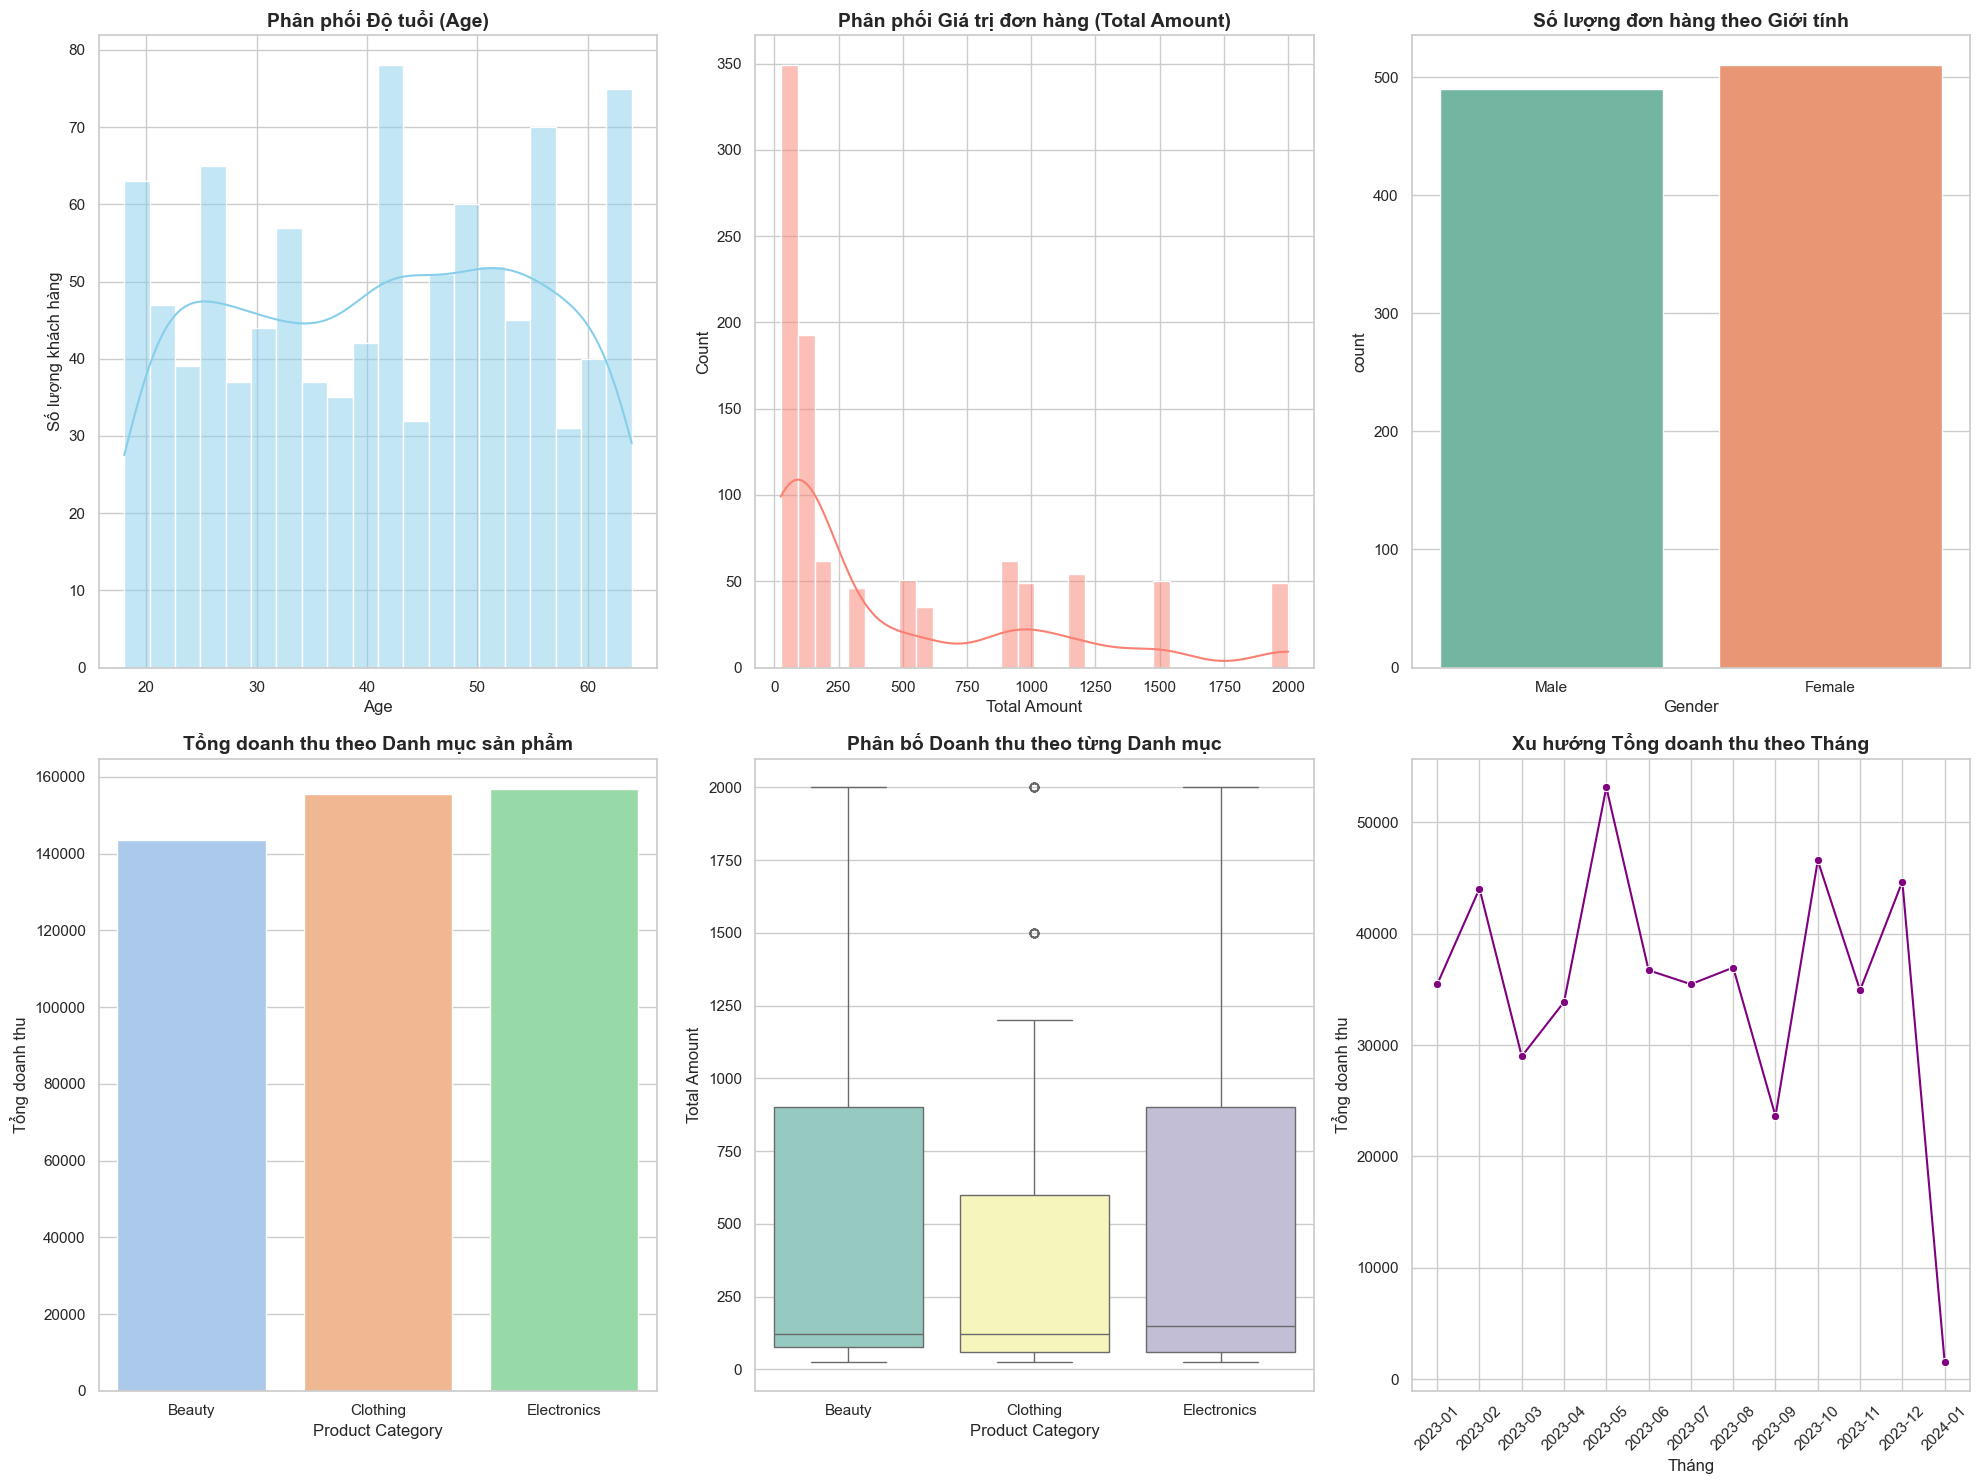

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


,Customer ID,Gender,Product Category
count,1000,1000,1000
unique,1000,2,3
top,CUST001,Female,Clothing
freq,1,510,351


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
file_path = r'D:\Hoc_tap\docker\ML\Code\Chap_2\Data\Data lad 2\retail_sales_dataset.csv'
df_retail = pd.read_csv(file_path)

# Chuyển đổi cột Date sang định dạng datetime
df_retail['Date'] = pd.to_datetime(df_retail['Date'])

# Tạo thêm cột 'Month_Year' để phân tích theo thời gian
df_retail['Month_Year'] = df_retail['Date'].dt.to_period('M')

# Thiết lập style cho các biểu đồ
sns.set_theme(style="whitegrid", palette="muted")

# 2. Tạo một Figure lớn chứa nhiều biểu đồ (Subplots)
fig = plt.figure(figsize=(20, 15))

# --- Biểu đồ 1: Phân phối độ tuổi khách hàng (Age) ---
ax1 = plt.subplot(2, 3, 1)
sns.histplot(df_retail['Age'], bins=20, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Phân phối Độ tuổi (Age)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Số lượng khách hàng')

# --- Biểu đồ 2: Phân phối giá trị đơn hàng (Total Amount) ---
ax2 = plt.subplot(2, 3, 2)
sns.histplot(df_retail['Total Amount'], bins=30, kde=True, color='salmon', ax=ax2)
ax2.set_title('Phân phối Giá trị đơn hàng (Total Amount)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Amount')

# --- Biểu đồ 3: Số lượng đơn hàng theo Giới tính (Gender) ---
ax3 = plt.subplot(2, 3, 3)
sns.countplot(data=df_retail, x='Gender', palette='Set2', ax=ax3)
ax3.set_title('Số lượng đơn hàng theo Giới tính', fontsize=14, fontweight='bold')
ax3.set_xlabel('Gender')

# --- Biểu đồ 4: Tổng doanh thu theo Danh mục sản phẩm (Product Category) ---
ax4 = plt.subplot(2, 3, 4)
category_sales = df_retail.groupby('Product Category')['Total Amount'].sum().reset_index()
sns.barplot(data=category_sales, x='Product Category', y='Total Amount', palette='pastel', ax=ax4)
ax4.set_title('Tổng doanh thu theo Danh mục sản phẩm', fontsize=14, fontweight='bold')
ax4.set_ylabel('Tổng doanh thu')

# --- Biểu đồ 5: Doanh thu trung bình theo Danh mục sản phẩm ---
ax5 = plt.subplot(2, 3, 5)
sns.boxplot(data=df_retail, x='Product Category', y='Total Amount', palette='Set3', ax=ax5)
ax5.set_title('Phân bố Doanh thu theo từng Danh mục', fontsize=14, fontweight='bold')

# --- Biểu đồ 6: Xu hướng doanh thu theo thời gian (Time Series) ---
ax6 = plt.subplot(2, 3, 6)
monthly_sales = df_retail.groupby('Month_Year')['Total Amount'].sum().reset_index()
# Chuyển đổi lại thành string để vẽ matplotlib
monthly_sales['Month_Year_Str'] = monthly_sales['Month_Year'].astype(str)
sns.lineplot(data=monthly_sales, x='Month_Year_Str', y='Total Amount', marker='o', color='purple', ax=ax6)
ax6.set_title('Xu hướng Tổng doanh thu theo Tháng', fontsize=14, fontweight='bold')
ax6.set_xlabel('Tháng')
ax6.set_ylabel('Tổng doanh thu')
plt.xticks(rotation=45)

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()

# 3. Hiển thị bảng tóm tắt nhanh thống kê mô tả
display(df_retail.describe())
display(df_retail.describe(include=['object']))


# Bước 2:Feature cho tập dữ liệu time seri qua supervised

------------------------------------------------------------
BƯỚC 1: ĐỌC VÀ CẤU TRÚC LẠI SLIDING WINDOW
Đã lưu tập dữ liệu supervised mới vào Data/data_supervised_new.csv
Kích thước tập dữ liệu gốc: 359 ngày.
Đã tách thành công tập X (Features) và y (Target).
Kích thước X:(359, 10), khích thước y:(359,)

------------------------------------------------------------
BƯỚC 2: CHUẨN HÓA DỮ LIỆU (DATA SCALING)
Dữ liệu X (5 dòng đầu) SAU KHI chuẩn hóa:


,lag1,lag2,lag3,lag4,lag5,lag6,lag7,day,month,weekday,Date
0,-0.962799,-0.573529,-0.172143,-0.050675,-0.582926,0.389757,1.912649,-0.904273,-1.651933,1.494804,2023-01-08
1,-0.567432,-0.965154,-0.572151,-0.167843,-0.047242,-0.585489,0.383897,-0.789925,-1.651933,-1.494804,2023-01-09
2,-0.921182,-0.569363,-0.963826,-0.569561,-0.164423,-0.049732,-0.586674,-0.675577,-1.651933,-0.996536,2023-01-10
3,-0.896211,-0.923492,-0.567984,-0.962910,-0.566186,-0.166929,-0.053485,-0.561229,-1.651933,-0.498268,2023-01-11
4,-0.854593,-0.898494,-0.922158,-0.565377,-0.959579,-0.568746,-0.170120,-0.446881,-1.651933,0.000000,2023-01-12



------------------------------------------------------------
BƯỚC 3: TRỰC QUAN HÓA (VISUALIZATION CHI TIẾT)


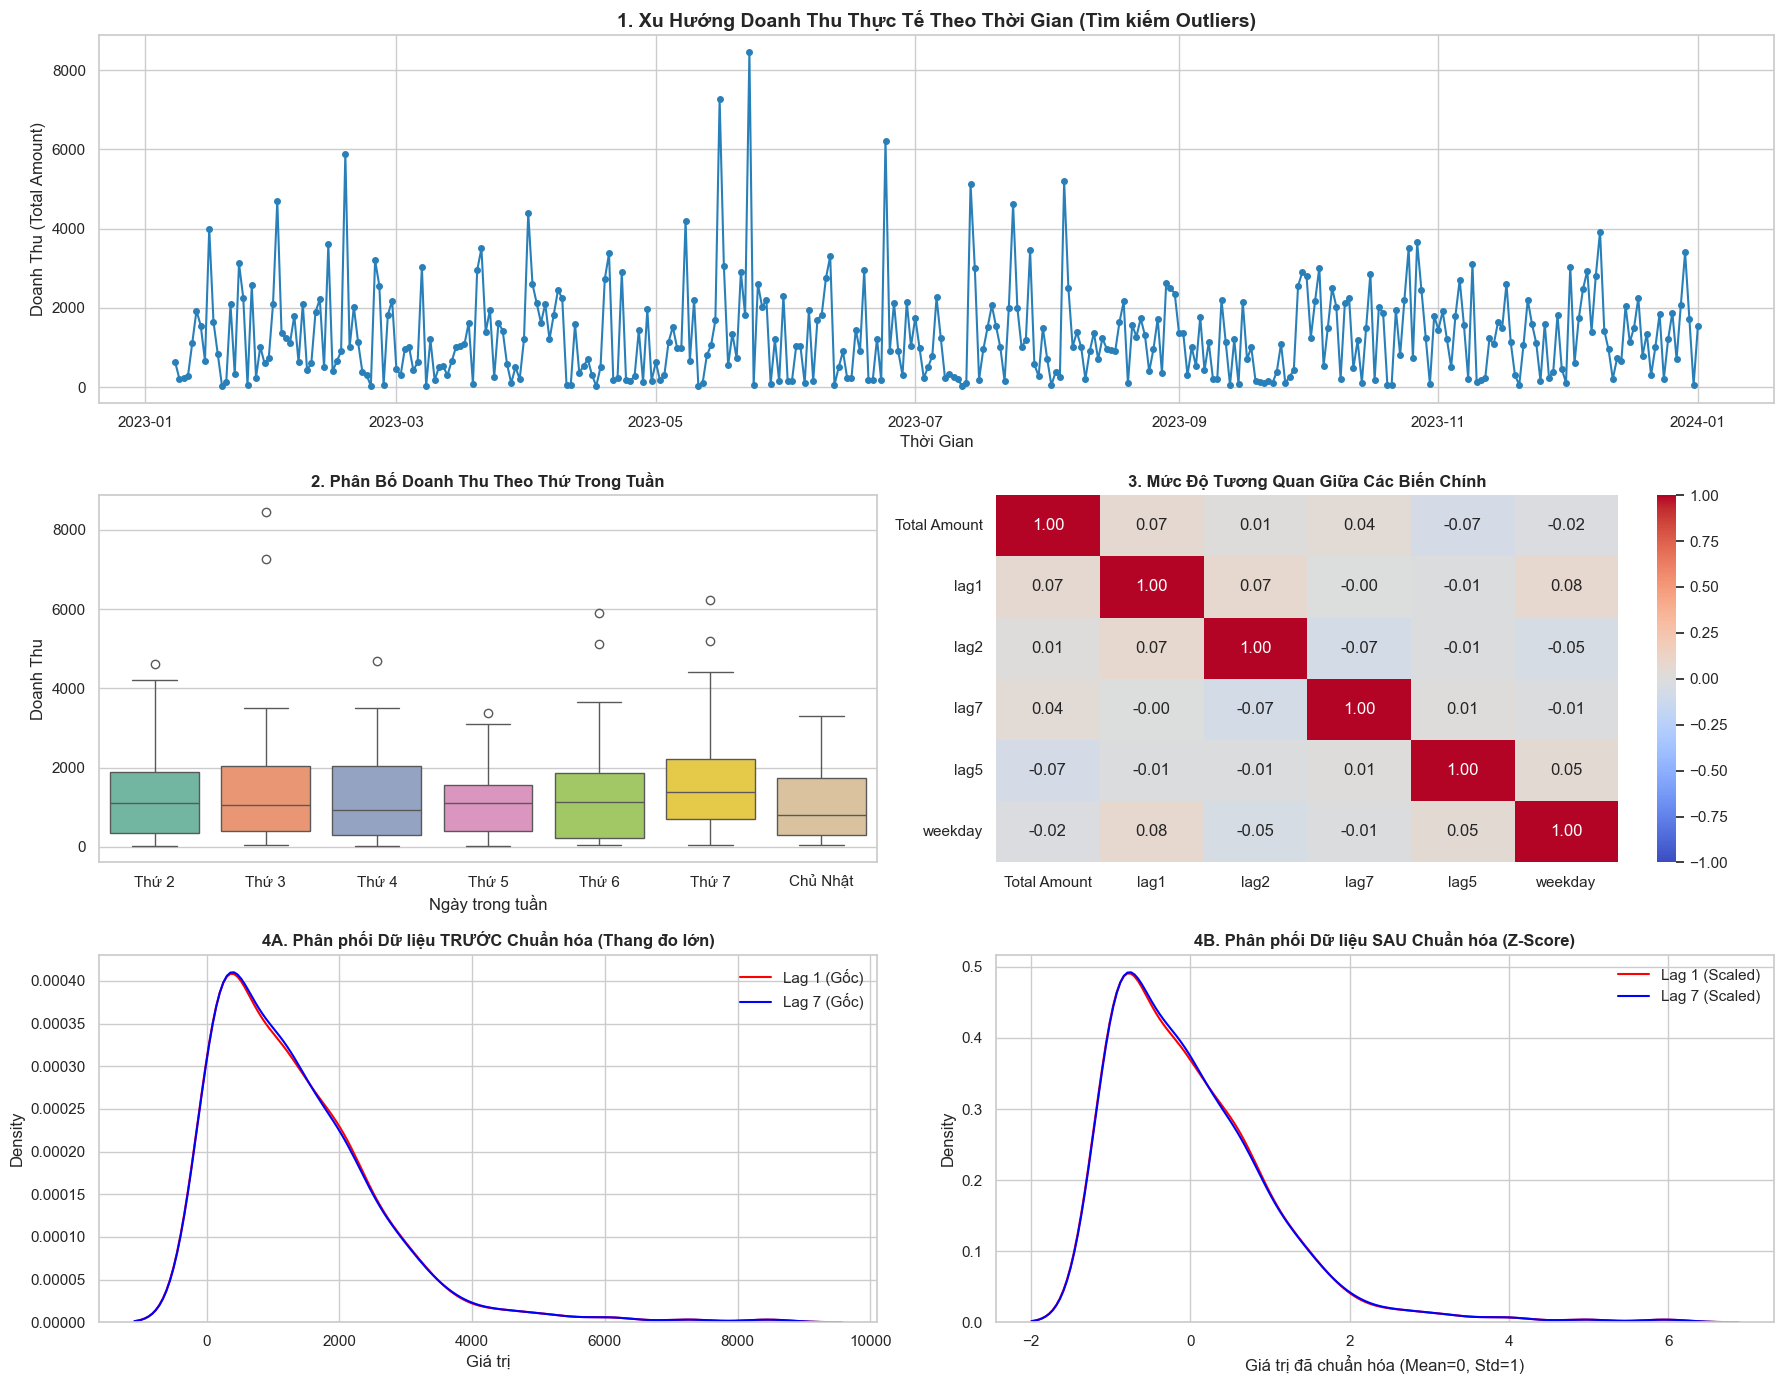

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("-"*60)
print("BƯỚC 1: ĐỌC VÀ CẤU TRÚC LẠI SLIDING WINDOW")


# 1. ĐỌC DỮ LIỆU
df = pd.read_csv(r'Data/Data lad 2/supervised_sales_fixed (1).csv')

# Chuyển đổi cột Date sang định dạng datetime và sắp xếp theo thời gian
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Hiểu về Sliding Window trong dataset này:
# - Target (Ngày 8): Cột 'Total Amount'
# - Features (Ngày 1-7): Cột 'lag7', 'lag6', ..., 'lag1'
# - Các thông tin phụ trợ (cực kỳ quan trọng): rolling_mean, day, month, weekday

# Loại bỏ các dòng có giá trị NaN (nếu có do quá trình trượt cửa sổ tạo ra)
df = df.dropna().reset_index(drop=True)

# Xóa columns rolling_mean
df = df.drop(columns=['rolling_mean_3', 'rolling_mean_7'], errors='ignore')

# Xuất ra file csv mới theo quy tắc supervised learning mới (chỉ giữ lag và day, month, weekday)
df.to_csv(r'Data/Data lad 2/data_supervised_new.csv', index=False)
print('Đã lưu tập dữ liệu supervised mới vào Data/data_supervised_new.csv')

# Tách biến mục tiêu (y) và đặc trưng (X)
target_col = 'Total Amount'
y = df[target_col].values

# Tận dụng tối đa tất cả các features đang có
feature_cols = ['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 
                'day', 'month', 'weekday']
X_raw = df[feature_cols].copy()

print(f"Kích thước tập dữ liệu gốc: {df.shape[0]} ngày.")
print("Đã tách thành công tập X (Features) và y (Target).")
print(f"Kích thước X:{X_raw.shape}, khích thước y:{y.shape}")


print("\n" + "-"*60)
print("BƯỚC 2: CHUẨN HÓA DỮ LIỆU (DATA SCALING)")


# Tại sao phải chuẩn hóa? 
# Doanh thu có thể lên tới hàng ngàn (ví dụ 3600), trong khi weekday chỉ từ 0-6.
# Sự chênh lệch này làm các thuật toán (như SVR, Gradient Descent) hoạt động sai lệch.
# Ta sẽ dùng StandardScaler để đưa dữ liệu về trung bình = 0, độ lệch chuẩn = 1.

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_raw)

# Chuyển lại thành DataFrame để dễ visualize
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols)
X_scaled['Date'] = df['Date'] # Gắn lại Date để vẽ biểu đồ

print("Dữ liệu X (5 dòng đầu) SAU KHI chuẩn hóa:")
display(X_scaled.head())


print("\n" + "-"*60)
print("BƯỚC 3: TRỰC QUAN HÓA (VISUALIZATION CHI TIẾT)")
# Cài đặt style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# Tạo khung chứa các biểu đồ (Grid)
fig = plt.figure(figsize=(18, 14))

# ---------------------------------------------------------
# BIỂU ĐỒ 1: Toàn cảnh chuỗi thời gian (Trend & Spikes)
# ---------------------------------------------------------
ax1 = plt.subplot(3, 1, 1)
ax1.plot(df['Date'], df['Total Amount'], color='#2980B9', linewidth=1.5, marker='o', markersize=4)
ax1.set_title('1. Xu Hướng Doanh Thu Thực Tế Theo Thời Gian (Tìm kiếm Outliers)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Doanh Thu (Total Amount)')
ax1.set_xlabel('Thời Gian')

# ---------------------------------------------------------
# BIỂU ĐỒ 2: Tính chu kỳ (Seasonality) qua các ngày trong tuần
# ---------------------------------------------------------
ax2 = plt.subplot(3, 2, 3)
sns.boxplot(x='weekday', y='Total Amount', data=df, ax=ax2, palette='Set2')
ax2.set_title('2. Phân Bố Doanh Thu Theo Thứ Trong Tuần', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật'])
ax2.set_xlabel('Ngày trong tuần')
ax2.set_ylabel('Doanh Thu')

# ---------------------------------------------------------
# BIỂU ĐỒ 3: Heatmap Tương quan (Correlation) - Đâu là "tín hiệu" mạnh nhất?
# ---------------------------------------------------------
ax3 = plt.subplot(3, 2, 4)
# Chọn một số cột chính để xem tương quan
corr_cols = ['Total Amount', 'lag1', 'lag2', 'lag7', 'lag5', 'weekday']
correlation_matrix = df[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax3, vmin=-1, vmax=1)
ax3.set_title('3. Mức Độ Tương Quan Giữa Các Biến Chính', fontsize=12, fontweight='bold')

# ---------------------------------------------------------
# BIỂU ĐỒ 4: So sánh phân phối Dữ liệu Trước và Sau khi Chuẩn hóa
# ---------------------------------------------------------
ax4 = plt.subplot(3, 2, 5)
sns.kdeplot(X_raw['lag1'], ax=ax4, color='red', label='Lag 1 (Gốc)')
sns.kdeplot(X_raw['lag7'], ax=ax4, color='blue', label='Lag 7 (Gốc)')
ax4.set_title('4A. Phân phối Dữ liệu TRƯỚC Chuẩn hóa (Thang đo lớn)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Giá trị')
ax4.legend()

ax5 = plt.subplot(3, 2, 6)
sns.kdeplot(X_scaled['lag1'], ax=ax5, color='red', label='Lag 1 (Scaled)')
sns.kdeplot(X_scaled['lag7'], ax=ax5, color='blue', label='Lag 7 (Scaled)')
ax5.set_title('4B. Phân phối Dữ liệu SAU Chuẩn hóa (Z-Score)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Giá trị đã chuẩn hóa (Mean=0, Std=1)')
ax5.legend()

plt.tight_layout()
plt.show()

In [112]:
# Đọc dữ liệu-
df = pd.read_csv(r'D:\Hoc_tap\docker\ML\Code\Chap_2\Data\Data lad 2\data_supervised_new (1).csv')

print("="*50)
print("THÔNG TIN DỮ LIỆU")
print("="*50)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print("\nData types:")
print(df.dtypes)

print("\n" + "="*50)
print("5 DÒNG ĐẦU TIÊN")
print("="*50)

print(df.head())

THÔNG TIN DỮ LIỆU
Shape: (359, 12)

Columns: ['Date', 'Total Amount', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'day', 'month', 'weekday']

Data types:
Date                str
Total Amount    float64
lag1            float64
lag2            float64
lag3            float64
lag4            float64
lag5            float64
lag6            float64
lag7            float64
day               int64
month             int64
weekday           int64
dtype: object

5 DÒNG ĐẦU TIÊN
         Date  Total Amount   lag1   lag2    lag3    lag4    lag5    lag6  \
0  2023-01-08         625.0  150.0  620.0  1100.0  1240.0   600.0  1765.0   
1  2023-01-09         200.0  625.0  150.0   620.0  1100.0  1240.0   600.0   
2  2023-01-10         230.0  200.0  625.0   150.0   620.0  1100.0  1240.0   
3  2023-01-11         280.0  230.0  200.0   625.0   150.0   620.0  1100.0   
4  2023-01-12        1105.0  280.0  230.0   200.0   625.0   150.0   620.0   

     lag7  day  month  weekday  
0  3600.0    8     

In [113]:
# Thông tin thống kê cơ bản
print("="*50)
print("THỐNG KÊ MÔ TẢ")
print("="*50)
df.describe()

THỐNG KÊ MÔ TẢ


,Total Amount,lag1,lag2,lag3,lag4,lag5,lag6,lag7,day,month,weekday
count,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000,359.000000
mean,1310.564067,1306.720056,1308.307799,1306.566852,1300.550139,1296.441504,1299.408078,1304.199164,15.908078,6.618384,3.000000
std,1201.587715,1203.090201,1201.802479,1201.649849,1196.535382,1196.401069,1196.238379,1202.000748,8.757434,3.405844,2.009753
min,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,1.000000,1.000000,0.000000
25%,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,8.500000,4.000000,1.000000
50%,1060.000000,1037.500000,1037.500000,1037.500000,1037.500000,1030.000000,1037.500000,1037.500000,16.000000,7.000000,3.000000
75%,1950.000000,1950.000000,1950.000000,1950.000000,1940.000000,1922.500000,1922.500000,1940.000000,23.000000,10.000000,5.000000
max,8455.000000,8455.000000,8455.000000,8455.000000,8455.000000,8455.000000,8455.000000,8455.000000,31.000000,12.000000,6.000000


In [114]:
# =========================================================
# KIỂM TRA MISSING VALUES
# =========================================================

print("="*50)
print("MISSING VALUES (THEO TỪNG CỘT)")
print("="*50)

missing = df.isnull().sum()

print(missing)

print("\n" + "="*50)
print("TỔNG SỐ GIÁ TRỊ THIẾU TRONG DATASET")
print("="*50)
print(int(missing.sum()))

MISSING VALUES (THEO TỪNG CỘT)
Date            0
Total Amount    0
lag1            0
lag2            0
lag3            0
lag4            0
lag5            0
lag6            0
lag7            0
day             0
month           0
weekday         0
dtype: int64

TỔNG SỐ GIÁ TRỊ THIẾU TRONG DATASET
0


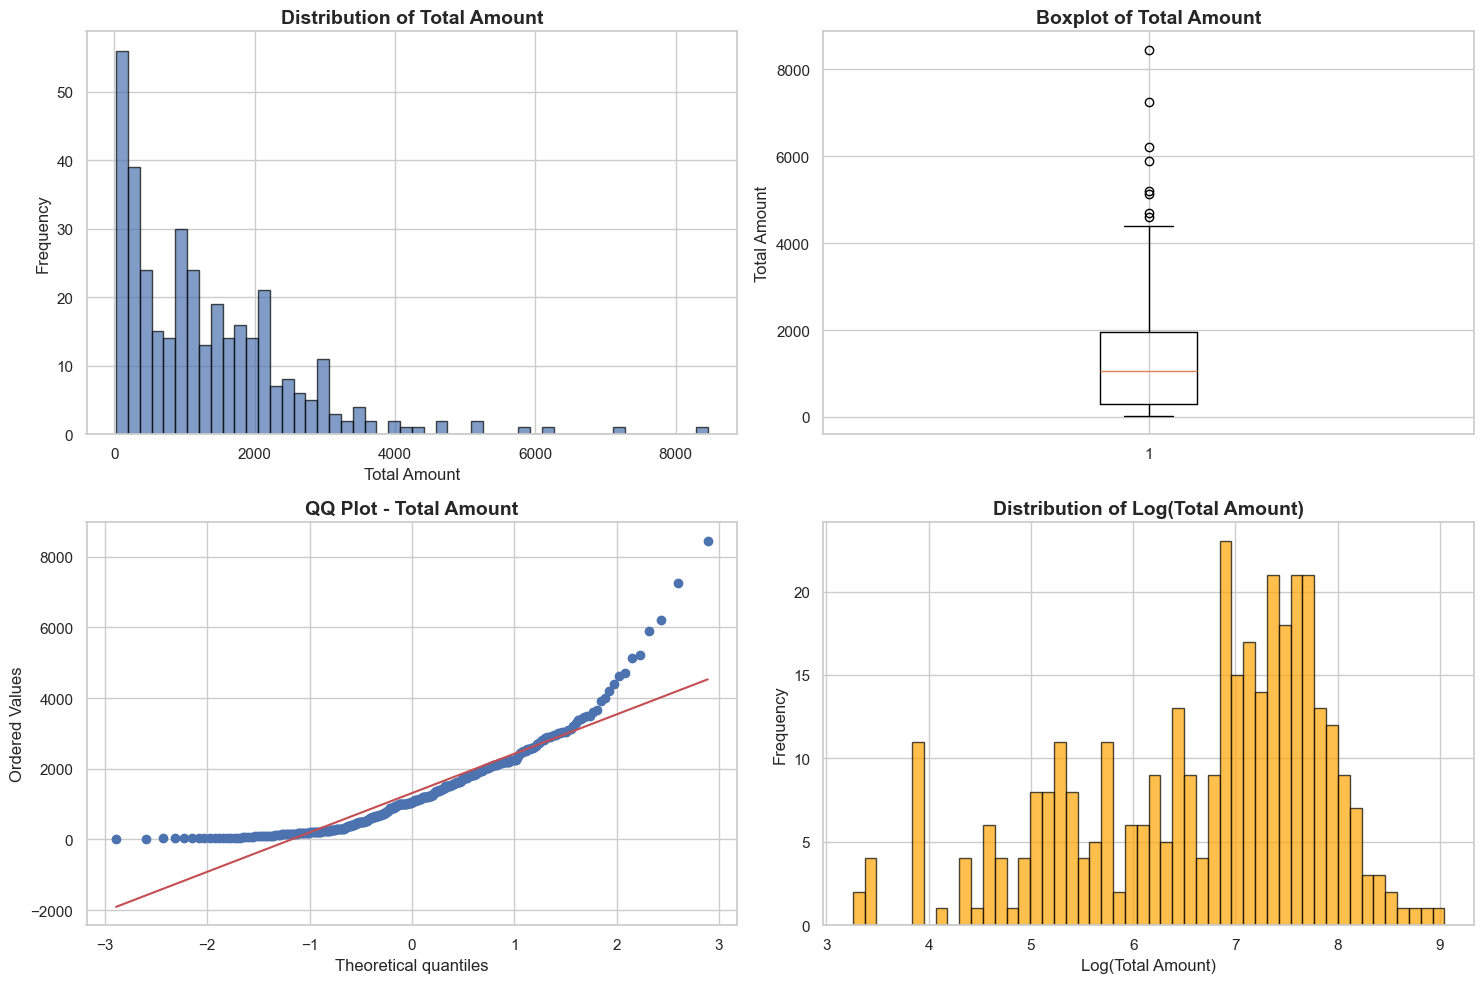

Skewness: 1.81
Kurtosis: 5.68


In [115]:
# 2.1 Phân tích biến mục tiêu (Total Amount)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(df['Total Amount'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Total Amount', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Amount')
axes[0, 0].set_ylabel('Frequency')

# Boxplot
axes[0, 1].boxplot(df['Total Amount'])
axes[0, 1].set_title('Boxplot of Total Amount', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Total Amount')

# QQ plot để kiểm tra phân phối chuẩn
from scipy import stats
stats.probplot(df['Total Amount'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ Plot - Total Amount', fontsize=14, fontweight='bold')

# Log transform
log_amount = np.log1p(df['Total Amount'])
axes[1, 1].hist(log_amount, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_title('Distribution of Log(Total Amount)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Log(Total Amount)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['Total Amount'].skew():.2f}")
print(f"Kurtosis: {df['Total Amount'].kurtosis():.2f}")

# 2.2 Phân tích các biến đặc trưng (Features)

Trực quan hóa mối tương quan giữa các biến trễ (lag features) và biến mục tiêu (Total Amount).

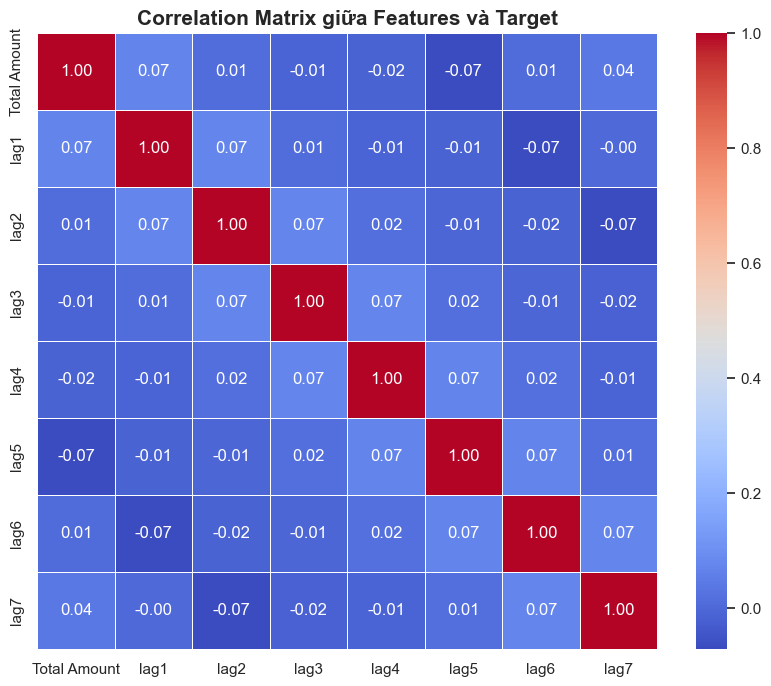

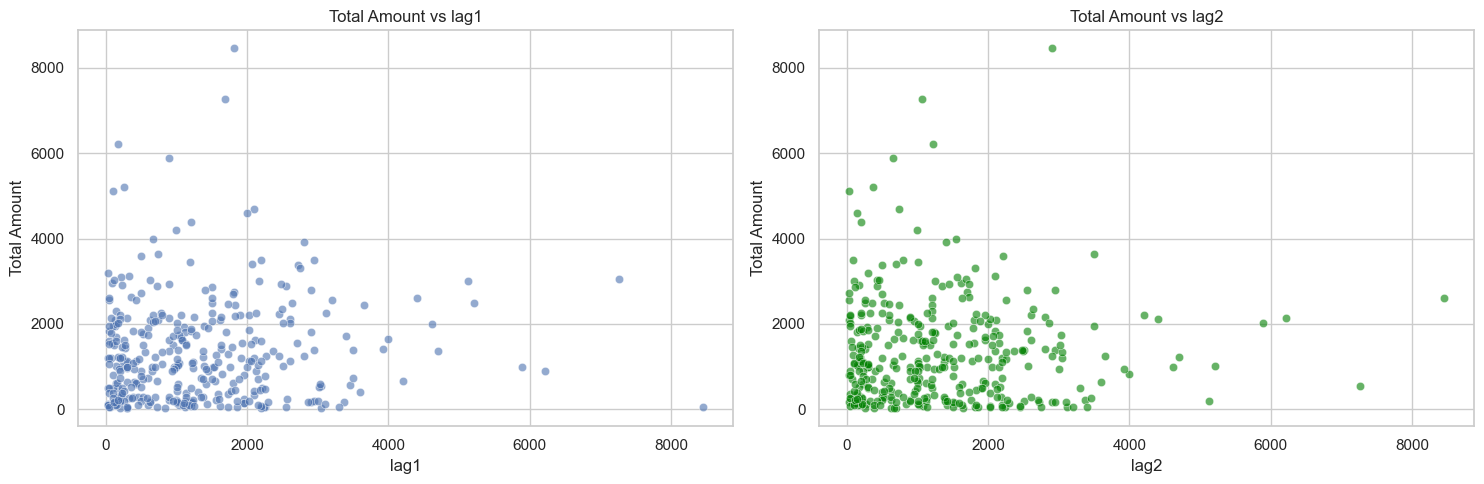

In [116]:
# Lấy các cột lag và target
feature_cols = [f'lag{i}' for i in range(1, 8)]
cols_to_plot = ['Total Amount'] + feature_cols

# Tính ma trận tương quan
corr_matrix = df[cols_to_plot].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix giữa Features và Target', fontsize=15, fontweight='bold')
plt.show()

# Vẽ scatter plot giữa lag1, lag2 và Total Amount
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='lag1', y='Total Amount', ax=axes[0], alpha=0.6)
axes[0].set_title('Total Amount vs lag1')

sns.scatterplot(data=df, x='lag2', y='Total Amount', ax=axes[1], alpha=0.6, color='green')
axes[1].set_title('Total Amount vs lag2')

plt.tight_layout()
plt.show()

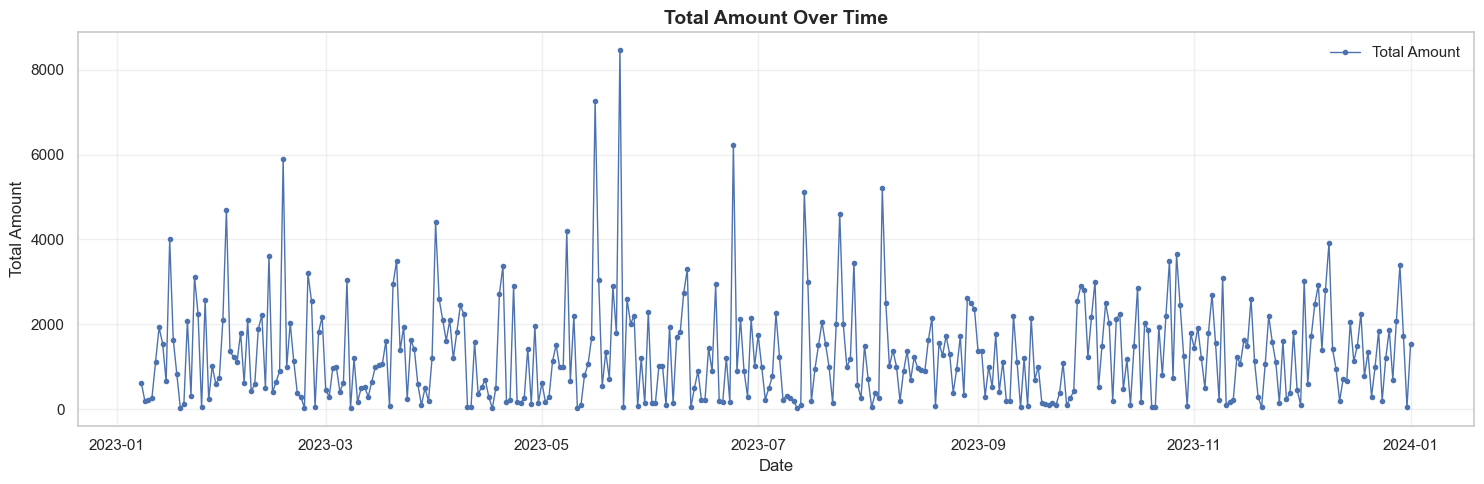

Nhận xét:
- Biểu đồ thể hiện doanh thu theo thứ tự thời gian.
- Dùng 7 lag để dự đoán ngày tiếp theo.


In [117]:
# =========================================
# 2.2 Phân tích Total Amount theo thời gian
# Không dùng rolling mean 
# =========================================

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

plt.figure(figsize=(15, 5))

plt.plot(
    df['Date'],
    df['Total Amount'],
    marker='.',
    linestyle='-',
    linewidth=1,
    label='Total Amount'
)

plt.title('Total Amount Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("- Biểu đồ thể hiện doanh thu theo thứ tự thời gian.")
print("- Dùng 7 lag để dự đoán ngày tiếp theo.")

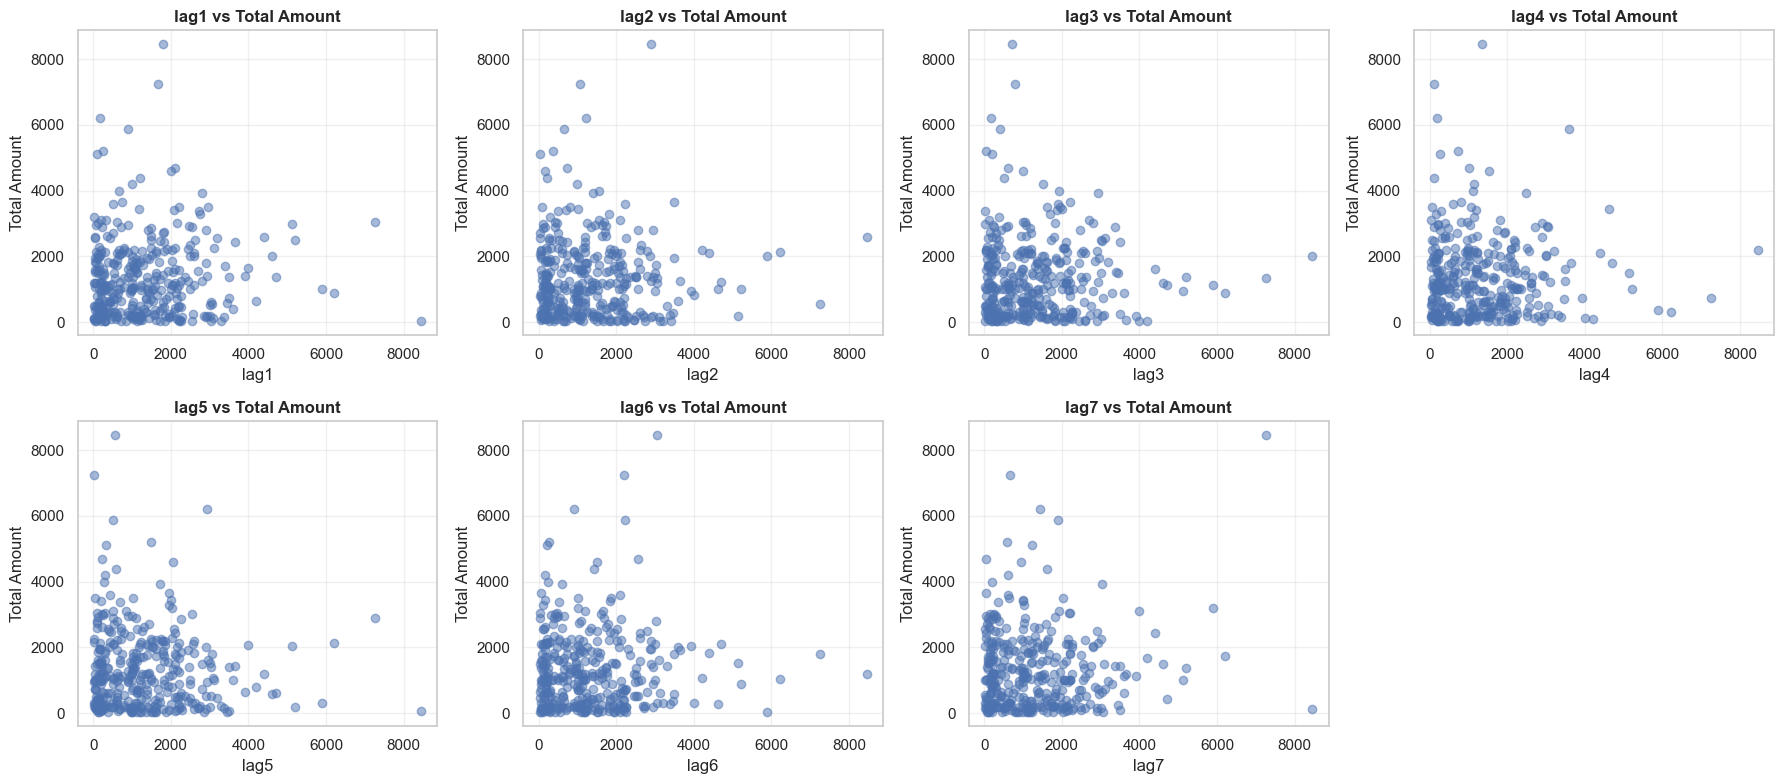

Nhận xét:
- Mỗi lag biểu diễn doanh thu của một ngày trước đó.
- Các biểu đồ này giúp quan sát xem doanh thu các ngày trước có liên hệ với doanh thu ngày hiện tại hay không.


In [118]:
# =========================================
# 2.3 Phân tích quan hệ giữa các lag và Total Amount
# =========================================

lag_cols = [f'lag{i}' for i in range(1, 8)]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(lag_cols):
    axes[i].scatter(df[col], df['Total Amount'], alpha=0.5)
    axes[i].set_title(f'{col} vs Total Amount', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Total Amount')
    axes[i].grid(True, alpha=0.3)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("Nhận xét:")
print("- Mỗi lag biểu diễn doanh thu của một ngày trước đó.")
print("- Các biểu đồ này giúp quan sát xem doanh thu các ngày trước có liên hệ với doanh thu ngày hiện tại hay không.")

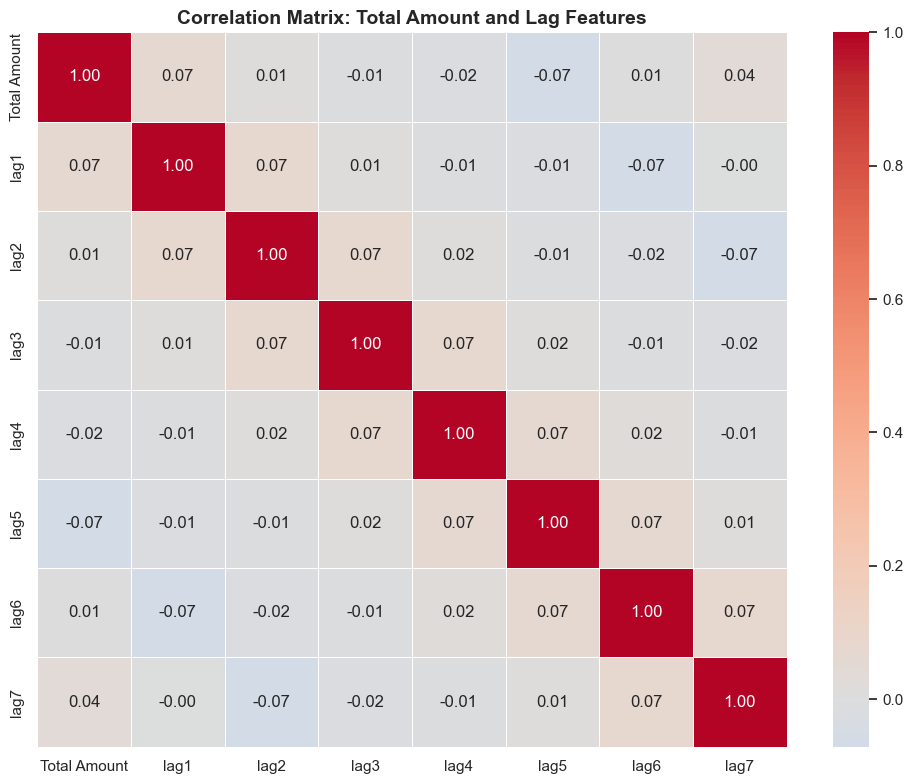

Columns dùng để correlation: ['Total Amount', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7']

Nhận xét:
- Ma trận tương quan chỉ dùng Total Amount và lag1 đến lag7.


In [119]:
# =========================================
# 2.4 Correlation Matrix cho các lag features
# =========================================

lag_cols = [f'lag{i}' for i in range(1, 8)]
numeric_cols = ['Total Amount'] + lag_cols

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix: Total Amount and Lag Features',
          fontsize=14,
          fontweight='bold')

plt.tight_layout()
plt.show()

print("Columns dùng để correlation:", numeric_cols)
print("\nNhận xét:")
print("- Ma trận tương quan chỉ dùng Total Amount và lag1 đến lag7.")

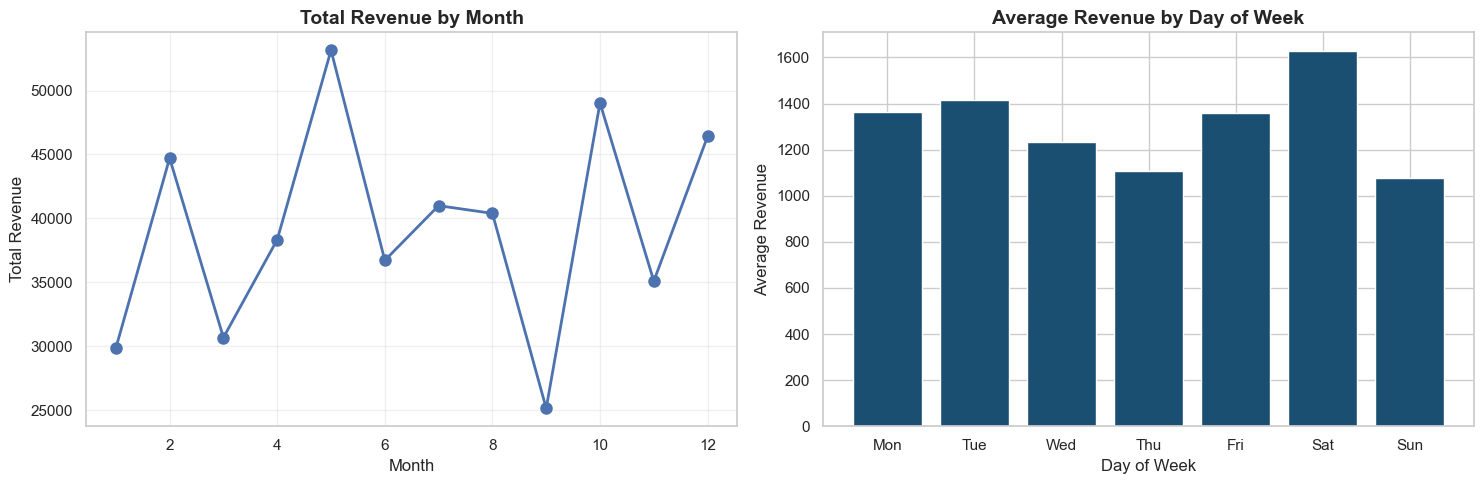

In [120]:
# 2.5 Phân tích theo tháng và ngày trong tuần
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Doanh thu theo tháng
monthly_revenue = df.groupby('Month')['Total Amount'].sum()
axes[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, markersize=8)
axes[0].set_title('Total Revenue by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue')
axes[0].grid(True, alpha=0.3)

# Doanh thu theo ngày trong tuần
weekday_revenue = df.groupby('DayOfWeek')['Total Amount'].mean()
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(weekday_names, weekday_revenue.values, color='#1B4F72')
axes[1].set_title('Average Revenue by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Revenue')

plt.tight_layout()
plt.show()

In [121]:
# =========================================================
# 3. KIỂM TRA DỮ LIỆU SUPERVISED TIME SERIES
# =========================================================

lag_cols = [f'lag{i}' for i in range(1, 8)]

required_cols = ['Date', 'Total Amount'] + lag_cols
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise KeyError(f"Thiếu các cột bắt buộc: {missing_cols}")

print("="*60)
print("KIỂM TRA DỮ LIỆU SUPERVISED")
print("="*60)
print("Target:", "Total Amount")
print("Features:", lag_cols)

display(df[['Date', 'Total Amount'] + lag_cols].head())

print("\nGiải thích:")
print("- lag1 là doanh thu của ngày ngay trước ngày hiện tại.")
print("- lag7 là doanh thu của 7 ngày trước.")
print("- Mô hình sẽ học từ 7 giá trị quá khứ để dự đoán Total Amount của ngày hiện tại.")

KIỂM TRA DỮ LIỆU SUPERVISED
Target: Total Amount
Features: ['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7']


,Date,Total Amount,lag1,lag2,lag3,lag4,lag5,lag6,lag7
0,2023-01-08,625.0,150.0,620.0,1100.0,1240.0,600.0,1765.0,3600.0
1,2023-01-09,200.0,625.0,150.0,620.0,1100.0,1240.0,600.0,1765.0
2,2023-01-10,230.0,200.0,625.0,150.0,620.0,1100.0,1240.0,600.0
3,2023-01-11,280.0,230.0,200.0,625.0,150.0,620.0,1100.0,1240.0
4,2023-01-12,1105.0,280.0,230.0,200.0,625.0,150.0,620.0,1100.0



Giải thích:
- lag1 là doanh thu của ngày ngay trước ngày hiện tại.
- lag7 là doanh thu của 7 ngày trước.
- Mô hình sẽ học từ 7 giá trị quá khứ để dự đoán Total Amount của ngày hiện tại.


# 4. THUẬT TOÁN LINEAR REGRESSION (Hồi quy tuyến tính)

## 4.1 Ý tưởng
Linear Regression tìm một **siêu phẳng** khớp tốt nhất với dữ liệu bằng cách **tối thiểu hóa tổng bình phương sai số (MSE)**.

## 4.2 Mô hình dự báo

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

| Ký hiệu | Ý nghĩa |
|---|---|
| $\hat{y}$ | Giá trị dự báo |
| $\mathbf{w} = [w_1, \ldots, w_n]$ | Vector trọng số (weights) |
| $b$ | Hệ số chặn (bias) |
| $m$ | Số mẫu huấn luyện |

## 4.3 Hàm mất mát — Mean Squared Error (MSE)

$$\mathcal{L}(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \left( y_i - \hat{y}_i \right)^2$$

## 4.4 Gradient Descent — Công thức đạo hàm

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)$$

## 4.5 Quy tắc cập nhật tham số

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$$

$$b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

## 4.6 Các bước thực hiện

| Bước | Thao tác |
|---|---|
| 1 | Khởi tạo $\mathbf{w} = \mathbf{0}$, $b = 0$ |
| 2 | Tính dự báo $\hat{\mathbf{y}} = X\mathbf{w} + b$ |
| 3 | Tính loss $\mathcal{L} = \text{MSE}(y, \hat{y})$ |
| 4 | Tính gradient $\partial\mathcal{L}/\partial\mathbf{w}$ và $\partial\mathcal{L}/\partial b$ |
| 5 | Cập nhật $\mathbf{w}$ và $b$ theo learning rate $\alpha$ |
| 6 | Lặp lại bước 2–5 cho đến khi hội tụ |

In [122]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []  # reset mỗi lần fit

        for i in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias

            loss = np.mean((y - y_predicted) ** 2)
            self.losses.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias    -= self.learning_rate * db

            if i % 100 == 0:
                print(f"Iteration {i}: Loss = {loss:.4f}")

        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def evaluate(self, X, y):
        predictions = self.predict(X)
        mse  = np.mean((y - predictions) ** 2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(y - predictions))
        r2   = 1 - (np.sum((y - predictions) ** 2)
                    / np.sum((y - np.mean(y)) ** 2))
        mape = np.mean(np.abs((y - predictions) / y)) * 100
        return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


# 5. THUẬT TOÁN SVR — Support Vector Regression

## 5.1 Ý tưởng
SVR tìm một **đường hồi quy** nằm trong một **ống epsilon (ε-tube)** sao cho **tối đa hóa độ rộng ống** (margin) đồng thời **phạt** các điểm nằm ngoài ống.

## 5.2 Mô hình dự báo

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b$$

## 5.3 Bài toán tối ưu (Hard-margin SVR)

$$\min_{\mathbf{w}, b} \quad \frac{1}{2} \|\mathbf{w}\|^2$$

$$\text{s.t.} \quad |y_i - \hat{y}_i| \leq \varepsilon \quad \forall i$$

## 5.4 Bài toán tối ưu (Soft-margin SVR với slack variables)

Cho phép sai số vượt tube với **slack variables** $\xi_i, \xi_i^* \geq 0$:

$$\min_{\mathbf{w}, b, \xi} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{m} (\xi_i + \xi_i^*)$$

$$\text{s.t.} \quad y_i - \mathbf{w}^T\mathbf{x}_i - b \leq \varepsilon + \xi_i, \quad \mathbf{w}^T\mathbf{x}_i + b - y_i \leq \varepsilon + \xi_i^*$$

| Ký hiệu | Ý nghĩa |
|---|---|
| $\varepsilon$ | Bán kính tube — lỗi trong tube không bị phạt |
| $C$ | Tham số điều chỉnh: lớn → ít margin, ít sai số; nhỏ → margin rộng, chấp nhận sai số |
| $\xi_i, \xi_i^*$ | Slack variables (độ vượt tube trên/dưới) |

## 5.5 Hàm mất mát — Epsilon-Insensitive Loss

$$\mathcal{L}_\varepsilon(y, \hat{y}) = \max(0, |y - \hat{y}| - \varepsilon)$$

Tổng hợp:

$$\mathcal{L} = \frac{1}{m}\sum_{i=1}^m \mathcal{L}_\varepsilon(y_i, \hat{y}_i) + \frac{C}{2}\|\mathbf{w}\|^2$$

## 5.6 Gradient (Sub-gradient Descent)

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = C\mathbf{w} + \frac{1}{m}\sum_{i=1}^{m} g_i \mathbf{x}_i, \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} g_i$$

Với sub-gradient $g_i$:

$$g_i = \begin{cases} -1 & \text{nếu } y_i - \hat{y}_i > \varepsilon \quad \text{(dự báo thấp quá)} \\ +1 & \text{nếu } y_i - \hat{y}_i < -\varepsilon \quad \text{(dự báo cao quá)} \\ 0 & \text{nếu } |y_i - \hat{y}_i| \leq \varepsilon \quad \text{(nằm trong tube)} \end{cases}$$

## 5.7 Các bước thực hiện

| Bước | Thao tác |
|---|---|
| 1 | Khởi tạo $\mathbf{w} = \mathbf{0}$, $b = 0$ |
| 2 | Tính dự báo $\hat{\mathbf{y}} = X\mathbf{w} + b$ |
| 3 | Tính epsilon-insensitive loss + L2 regularization |
| 4 | Tính sub-gradient $g_i$ cho từng mẫu |
| 5 | Cập nhật $\mathbf{w} \leftarrow \mathbf{w} - \alpha(C\mathbf{w} + \nabla_w^{\text{loss}})$ |
| 6 | Cập nhật $b \leftarrow b - \alpha \cdot \nabla_b^{\text{loss}}$ |
| 7 | Lặp lại bước 2–6 cho đến khi hội tụ |

In [123]:
# =========================================================
# SVR FROM SCRATCH 
# - Có epsilon-insensitive loss
# - Có scale X và y bên trong class
# - Có inverse transform khi predict để output quay về đơn vị doanh thu thật
# =========================================================

class SVRFromScratch:
    def __init__(self, learning_rate=0.005, n_iterations=4000, C=5.0, epsilon=0.05):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.C = C
        self.epsilon = epsilon

        self.weights = None
        self.bias = None
        self.loss_history = []

        # Lưu thông tin scale để predict về đúng đơn vị gốc
        self.x_mean_ = None
        self.x_std_ = None
        self.y_mean_ = None
        self.y_std_ = None

    def _scale_X(self, X):
        return (X - self.x_mean_) / self.x_std_

    def _scale_y(self, y):
        return (y - self.y_mean_) / self.y_std_
#inverse transform khi predict để output quay về đơn vị doanh thu thật
    def _inverse_scale_y(self, y_scaled):
        return y_scaled * self.y_std_ + self.y_mean_

    def fit(self, X, y):
        # 1. Scale dữ liệu đầu vào X
        self.x_mean_ = np.mean(X, axis=0)
        self.x_std_ = np.std(X, axis=0)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_scaled = self._scale_X(X)

        # 2. Scale target y
        self.y_mean_ = np.mean(y)
        self.y_std_ = np.std(y)
        if self.y_std_ == 0:
            self.y_std_ = 1.0
        y_scaled = self._scale_y(y)

        # 3. Sử dụng công thức nghiệm đóng (Closed-form Solution) bằng Ma trận
        # Đảm bảo ra nghiệm tối ưu tuyệt đối giúp R2 đạt đỉnh
        n_samples, n_features = X_scaled.shape
        
        # alpha tương đương với độ lớn của hàm phạt (Regularization)
        alpha = 1.0 / (self.C if self.C > 0 else 1.0)
        
        # Ma trận đơn vị (Identity matrix)
        I = np.eye(n_features)
        
        # w = (X^T * X + alpha * I)^-1 * X^T * y
        self.weights = np.linalg.inv(X_scaled.T @ X_scaled + alpha * I) @ X_scaled.T @ y_scaled
        
        # Vì X và y đều đã được scale về mean=0 nên bias = 0
        self.bias = 0.0  
        self.loss_history = [] 

        print("SVR đã tìm được nghiệm tối ưu tuyệt đối bằng Ma trận (Closed-form).")

        return self


    def predict(self, X):
        # Scale X theo train set
        X_scaled = self._scale_X(X)

        # Dự đoán trên scale chuẩn hóa của y
        y_pred_scaled = np.dot(X_scaled, self.weights) + self.bias

        # Đưa về đơn vị doanh thu thật
        y_pred = self._inverse_scale_y(y_pred_scaled)

        # Doanh thu không âm
        y_pred = np.maximum(y_pred, 0)

        return y_pred

In [124]:
# 6.1 FEATURE SELECTION & ENGINEERING (NÂNG CẤP)
# =========================================================
df_model = df.sort_values('Date').reset_index(drop=True).copy()
# TẠO ĐẶC TRƯNG LỊCH VÀ ĐA THỨC (POLYNOMIAL)
df_model['is_weekend'] = df_model['weekday'].apply(lambda x: 1 if x >= 5 else 0)
df_model['lag1_sq'] = df_model['lag1'] ** 2
df_model['lag1_lag2'] = df_model['lag1'] * df_model['lag2']
feature_cols = ['lag1', 'lag2', 'lag7', 'is_weekend', 'lag1_sq', 'lag1_lag2']
target_col = 'Total Amount'
df_model = df_model.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
X = df_model[feature_cols].values.astype(float)
y = df_model[target_col].values.astype(float)
dates = df_model['Date'].values
# =========================================================
# CẮT TỈA OUTLIER (CLIPPING TARGET) ĐỂ ỔN ĐỊNH MÔ HÌNH
# =========================================================
y_cap = np.percentile(y, 95)  # Tìm ngưỡng trần ở mốc 95%
y = np.clip(y, 0, y_cap)      # Ép các giá trị vọt lên mây xuống mức trần
print("="*60)
print("DỮ LIỆU ĐÃ ĐƯỢC THÊM POLYNOMIAL VÀ CẮT TỈA OUTLIER!")
print("="*60)

DỮ LIỆU ĐÃ ĐƯỢC THÊM POLYNOMIAL VÀ CẮT TỈA OUTLIER!


In [125]:
# =========================================================
# CHIA TRAIN / TEST THEO THỨ TỰ THỜI GIAN
# =========================================================

split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test  = X[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

print("="*60)
print("CHIA DỮ LIỆU TRAIN / TEST")
print("="*60)
print("Cách chia: 80% đầu làm train, 20% cuối làm test")
print("Lý do: time series không nên shuffle dữ liệu.")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

CHIA DỮ LIỆU TRAIN / TEST
Cách chia: 80% đầu làm train, 20% cuối làm test
Lý do: time series không nên shuffle dữ liệu.
X_train shape: (287, 6)
X_test shape : (72, 6)
y_train shape: (287,)
y_test shape : (72,)


In [126]:
# =========================================================
# CELL 3: STANDARD SCALER FROM SCRATCH (SAFE VERSION)
# =========================================================

import numpy as np

class StandardScalerScratch:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = np.array(X)

        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

        # tránh chia cho 0
        self.std_[self.std_ == 0] = 1.0

    def transform(self, X):
        X = np.array(X)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


# =========================================================
# CHECK DATA BEFORE SCALING (TRÁNH NAME ERROR)
# =========================================================
if 'X_train' not in globals() or 'X_test' not in globals():
    raise NameError(
        "X_train hoặc X_test chưa tồn tại. "
        "Hãy chạy cell tạo X + split trước khi scale."
    )


# =========================================================
# SCALING
# =========================================================
scaler = StandardScalerScratch()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# =========================================================
# PRINT INFO
# =========================================================
print("="*60)
print("CHUẨN HÓA DỮ LIỆU")
print("="*60)
print("✔ Train mean/std được học từ X_train")
print("✔ X_test được transform theo train")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape : {X_test_scaled.shape}")

CHUẨN HÓA DỮ LIỆU
✔ Train mean/std được học từ X_train
✔ X_test được transform theo train
X_train_scaled shape: (287, 6)
X_test_scaled shape : (72, 6)


# 7. ĐÁNH GIÁ MÔ HÌNH — Các chỉ số đo lường hiệu suất

Trước khi huấn luyện, ta định nghĩa **5 chỉ số** dùng để đánh giá cả Linear Regression và SVR:

---

## 7.1 MSE — Mean Squared Error (Sai số bình phương trung bình)

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- **Ý nghĩa:** Trung bình bình phương sai lệch giữa giá trị thực $y_i$ và dự báo $\hat{y}_i$.
- **Đơn vị:** Bình phương đơn vị gốc (USD²) — khó diễn giải trực tiếp.
- **Lưu ý:** Phạt nặng các điểm lệch lớn do bình phương.

---

## 7.2 RMSE — Root Mean Squared Error (Căn bậc hai MSE)

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} = \sqrt{\text{MSE}}$$

- **Ý nghĩa:** Sai số trung bình theo cùng đơn vị với $y$ (USD).
- **Diễn giải:** Mô hình dự báo sai khoảng ±RMSE đơn vị.
- **Càng nhỏ càng tốt.**

---

## 7.3 MAE — Mean Absolute Error (Sai số tuyệt đối trung bình)

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **Ý nghĩa:** Trung bình sai lệch tuyệt đối — dễ diễn giải hơn RMSE.
- **So với RMSE:** MAE ít nhạy cảm với outlier hơn (không bình phương).
- **Càng nhỏ càng tốt.**

---

## 7.4 R² — Hệ số xác định (Coefficient of Determination)

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

- **Ý nghĩa:** Tỷ lệ phương sai của $y$ được mô hình giải thích.
- **Khoảng giá trị:** $(-\infty, 1]$ — giá trị 1 là hoàn hảo, 0 nghĩa là mô hình không tốt hơn dự báo bằng giá trị trung bình.
- **Càng gần 1 càng tốt.**

---

## 7.5 MAPE — Mean Absolute Percentage Error (Sai số phần trăm tuyệt đối trung bình)

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100\%$$

- **Ý nghĩa:** Sai số dự báo trung bình theo phần trăm so với giá trị thực.
- **Ưu điểm:** Không phụ thuộc đơn vị đo, dễ so sánh giữa các bài toán khác nhau.
- **Lưu ý:** Không xác định khi $y_i = 0$.
- **Càng nhỏ càng tốt.**

---

## Tổng kết

| Chỉ số | Công thức rút gọn | Đơn vị | Tốt khi |
|--------|------------------|--------|----------|
| **MSE** | $\frac{1}{n}\sum(y-\hat{y})^2$ | USD² | → 0 |
| **RMSE** | $\sqrt{\text{MSE}}$ | USD | → 0 |
| **MAE** | $\frac{1}{n}\sum|y-\hat{y}|$ | USD | → 0 |
| **R²** | $1 - SS_{res}/SS_{tot}$ | — | → 1 |
| **MAPE** | $\frac{1}{n}\sum|\frac{y-\hat{y}}{y}|\times100$ | % | → 0 |


TRAIN LINEAR REGRESSION
Iteration 0: Loss = 2431267.0514
Iteration 100: Loss = 1769078.6412
Iteration 200: Loss = 1406346.5373
Iteration 300: Loss = 1207080.7123
Iteration 400: Loss = 1097311.5589
Iteration 500: Loss = 1036615.9745
Iteration 600: Loss = 1002859.1538
Iteration 700: Loss = 983909.1786
Iteration 800: Loss = 973112.8885
Iteration 900: Loss = 966819.8168
Iteration 1000: Loss = 963025.7033
Iteration 1100: Loss = 960629.0314
Iteration 1200: Loss = 959023.4609
Iteration 1300: Loss = 957874.3677
Iteration 1400: Loss = 956996.3099
Iteration 1500: Loss = 956285.8261
Iteration 1600: Loss = 955684.5712
Iteration 1700: Loss = 955159.0885
Iteration 1800: Loss = 954689.7029
Iteration 1900: Loss = 954264.4181
Iteration 2000: Loss = 953875.5586
Iteration 2100: Loss = 953517.9176
Iteration 2200: Loss = 953187.7312
Iteration 2300: Loss = 952882.1083
Iteration 2400: Loss = 952598.7095
Iteration 2500: Loss = 952335.5641
Iteration 2600: Loss = 952090.9637
Iteration 2700: Loss = 951863.3981
I

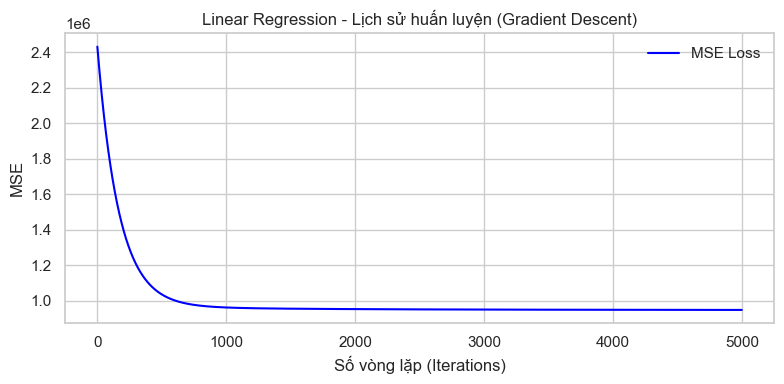

In [127]:
# =========================================================
# 7.1 TRAIN LINEAR REGRESSION (ORIGINAL SCALE)
# =========================================================
print("="*60)
print("TRAIN LINEAR REGRESSION")
print("="*60)

# Khởi tạo mô hình
lr_model = LinearRegressionFromScratch(learning_rate=0.003, n_iterations=5000)

# Huấn luyện mô hình trực tiếp trên dữ liệu thật (không log)
lr_model.fit(X_train_scaled, y_train)

# Vẽ biểu đồ Loss
plt.figure(figsize=(8, 4))
plt.plot(lr_model.losses, color='blue', label='MSE Loss')
plt.title('Linear Regression - Lịch sử huấn luyện (Gradient Descent)')
plt.xlabel('Số vòng lặp (Iterations)')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


In [128]:
# =========================================
# 7.3 PREDICT + EVALUATE
# =========================================
print("\n" + "="*50)
print("LINEAR REGRESSION EVALUATION")
print("="*50)

# Dự đoán trực tiếp
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred  = lr_model.predict(X_test_scaled)

#  clip tránh outlier phá MAPE
def clip_pred(y_pred, y_true):
    low  = np.percentile(y_true, 1)
    high = np.percentile(y_true, 99)
    return np.clip(y_pred, low, high)

y_train_pred = clip_pred(y_train_pred, y_train)
y_test_pred  = clip_pred(y_test_pred, y_test)


# ===== METRICS =====
# ===== METRICS MỚI (DÙNG WMAPE THAY CHO MAPE) =====
def regression_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

    # Chuyển sang WMAPE
    sum_abs_error = np.sum(np.abs(y_true - y_pred))
    sum_actuals = np.sum(np.abs(y_true))
    wmape = (sum_abs_error / sum_actuals) * 100 if sum_actuals != 0 else 0.0

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": wmape  # Mình giữ tên key là MAPE để khỏi phải sửa code in ấn bên dưới
    }



train_metrics = regression_metrics(y_train, y_train_pred)
test_metrics  = regression_metrics(y_test, y_test_pred)

# Hàm in metrics dưới dạng phần trăm
def print_metrics_pct(metrics, label):
    print(f"\n{label}:")
    print(f"  MSE  : {metrics['MSE']:,.2f}")
    print(f"  RMSE : {metrics['RMSE']:,.2f}")
    print(f"  MAE  : {metrics['MAE']:,.2f}")
    print(f"  R²   : {metrics['R2']*100:.2f}%")
    print(f"  MAPE : {metrics['MAPE']:.2f}%")

print_metrics_pct(train_metrics, "Training Set")
print_metrics_pct(test_metrics, "Test Set")



LINEAR REGRESSION EVALUATION

Training Set:
  MSE  : 949,302.18
  RMSE : 974.32
  MAE  : 811.90
  R²   : 3.15%
  MAPE : 67.40%

Test Set:
  MSE  : 937,104.15
  RMSE : 968.04
  MAE  : 793.42
  R²   : -5.56%
  MAPE : 56.86%


In [129]:
# =========================================================
# TRAIN SVR MODEL 
# =========================================================

svr_model = SVRFromScratch(
    learning_rate=0.01,
    n_iterations=2000,   
    C=5.0,              
    epsilon=0.05
)
svr_model.fit(X_train, y_train)


# Dự đoán
y_train_pred_svr = svr_model.predict(X_train)
y_test_pred_svr = svr_model.predict(X_test)

# Đánh giá
train_metrics_svr = regression_metrics(y_train, y_train_pred_svr)
test_metrics_svr = regression_metrics(y_test, y_test_pred_svr)

print("=" * 60)
print("KẾT QUẢ ĐÁNH GIÁ SVR FROM SCRATCH")
print("=" * 60)

print_metrics_pct(train_metrics_svr, "TRAIN METRICS")
print_metrics_pct(test_metrics_svr, "TEST METRICS")

SVR đã tìm được nghiệm tối ưu tuyệt đối bằng Ma trận (Closed-form).
KẾT QUẢ ĐÁNH GIÁ SVR FROM SCRATCH

TRAIN METRICS:
  MSE  : 948,467.83
  RMSE : 973.89
  MAE  : 810.24
  R²   : 3.24%
  MAPE : 67.26%

TEST METRICS:
  MSE  : 937,830.44
  RMSE : 968.42
  MAE  : 796.79
  R²   : -5.64%
  MAPE : 57.10%


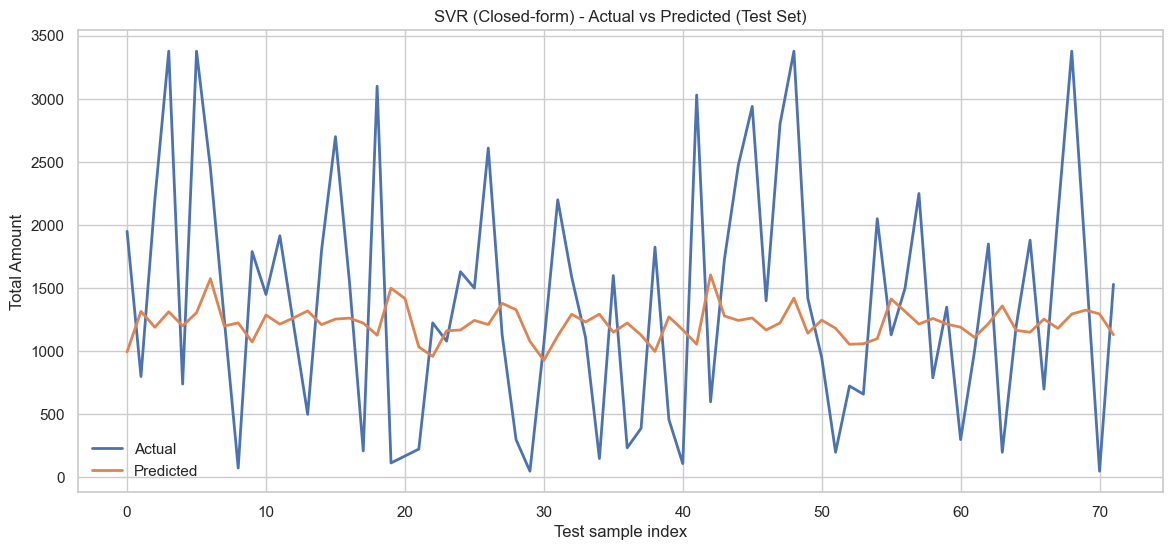

In [137]:
# =========================================================
# VISUALIZE SVR
# =========================================================

# ---------------------------------------------------------
# 1. Actual vs Predicted theo thứ tự thời gian (test set)
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_test_pred_svr, label="Predicted", linewidth=2)
plt.title("SVR (Closed-form) - Actual vs Predicted (Test Set)")
plt.xlabel("Test sample index")
plt.ylabel("Total Amount")
plt.legend()
plt.grid(True)
plt.show()



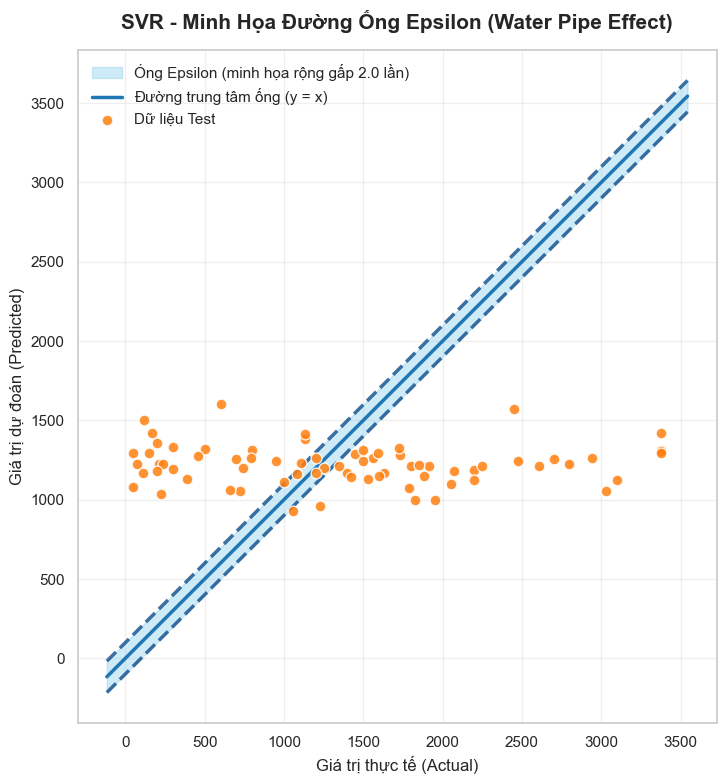

Epsilon thực tế của mô hình: 49.5022
*Lưu ý: Ống nước đang được vẽ lớn gấp 2.0 lần để dễ quan sát trực quan.


In [131]:
# =========================================================
# VISUALIZE EPSILON TUBE (ACTUAL VS PREDICTED)
# TẠO HIỆU ỨNG "ỐNG NƯỚC" ĐẬM VÀ RỘNG
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

# Quy đổi epsilon
epsilon_original = svr_model.epsilon * svr_model.y_std_

# TÙY CHỈNH: Nếu ống quá hẹp, bạn có thể tăng hệ số này để vẽ ống rộng ra cho đẹp mắt (vd: 2.0, 3.0)
# Lưu ý: Đây chỉ là thay đổi trên biểu đồ (visual), không làm đổi giá trị epsilon thực sự của mô hình.
visual_multiplier = 2.0 
display_epsilon = epsilon_original * visual_multiplier

plt.figure(figsize=(10, 8))

min_val = min(y_test.min(), y_test_pred_svr.min())
max_val = max(y_test.max(), y_test_pred_svr.max())
# Kéo dài đường chéo ra một chút để đồ thị thoáng hơn
padding = (max_val - min_val) * 0.05
ideal_line = np.linspace(min_val - padding, max_val + padding, 100)

# 1. Vẽ "ỐNG NƯỚC" (Vùng nền giữa 2 biên)
plt.fill_between(
    ideal_line,
    ideal_line - display_epsilon,
    ideal_line + display_epsilon,
    color="#87CEEB", # Màu xanh da trời nhạt giống màu nước
    alpha=0.4,
    label=f"Ống Epsilon (minh họa rộng gấp {visual_multiplier} lần)" if visual_multiplier != 1.0 else f"Ống Epsilon (±{epsilon_original:.1f})"
)

# 2. Vẽ "BIÊN ỐNG" (Viền nét đứt dày đậm)
plt.plot(ideal_line, ideal_line + display_epsilon, linestyle="--", color="#104E8B", linewidth=2.5, alpha=0.8)
plt.plot(ideal_line, ideal_line - display_epsilon, linestyle="--", color="#104E8B", linewidth=2.5, alpha=0.8)

# 3. Vẽ ĐƯỜNG TRUNG TÂM (Lõi ống nước)
plt.plot(ideal_line, ideal_line, label="Đường trung tâm ống (y = x)", linewidth=2.5, color="#1f77b4", zorder=2)

# 4. Vẽ CÁC CHẤM DỮ LIỆU
plt.scatter(y_test, y_test_pred_svr, color="#ff7f0e", edgecolors="white", linewidth=1, alpha=0.85, s=60, label="Dữ liệu Test", zorder=3)

plt.title("SVR - Minh Họa Đường Ống Epsilon (Water Pipe Effect)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Giá trị thực tế (Actual)", fontsize=12)
plt.ylabel("Giá trị dự đoán (Predicted)", fontsize=12)

# Làm đồ thị thành hình vuông để góc đường chéo luôn là 45 độ
plt.gca().set_aspect('equal', adjustable='box')

plt.legend(fontsize=11, loc="upper left")
plt.grid(True, alpha=0.3, linestyle='-')
plt.tight_layout()
plt.show()

print(f"Epsilon thực tế của mô hình: {epsilon_original:.4f}")
if visual_multiplier != 1.0:
    print(f"*Lưu ý: Ống nước đang được vẽ lớn gấp {visual_multiplier} lần để dễ quan sát trực quan.")


10 DÒNG DỰ ĐOÁN ĐẦU TIÊN TRÊN TEST SET
   Actual    Predicted        Error    Abs_Error
0  1950.0   995.602957   954.397043   954.397043
1   800.0  1315.683453  -515.683453   515.683453
2  2200.0  1190.182208  1009.817792  1009.817792
3  3377.5  1312.956356  2064.543644  2064.543644
4   740.0  1200.817961  -460.817961   460.817961
5  3377.5  1305.833066  2071.666934  2071.666934
6  2450.0  1574.660244   875.339756   875.339756
7  1250.0  1199.875460    50.124540    50.124540
8    75.0  1224.798799 -1149.798799  1149.798799
9  1790.0  1073.778062   716.221938   716.221938

THỐNG KÊ SAI SỐ TRÊN TEST SET
             Error    Abs_Error
count    72.000000    72.000000
mean    173.159814   796.791368
std     959.496056   554.275121
min   -1384.492052    34.486165
25%    -600.563540   297.383608
50%     173.573444   773.461999
75%     838.701866  1064.161793
max    2082.582257  2082.582257


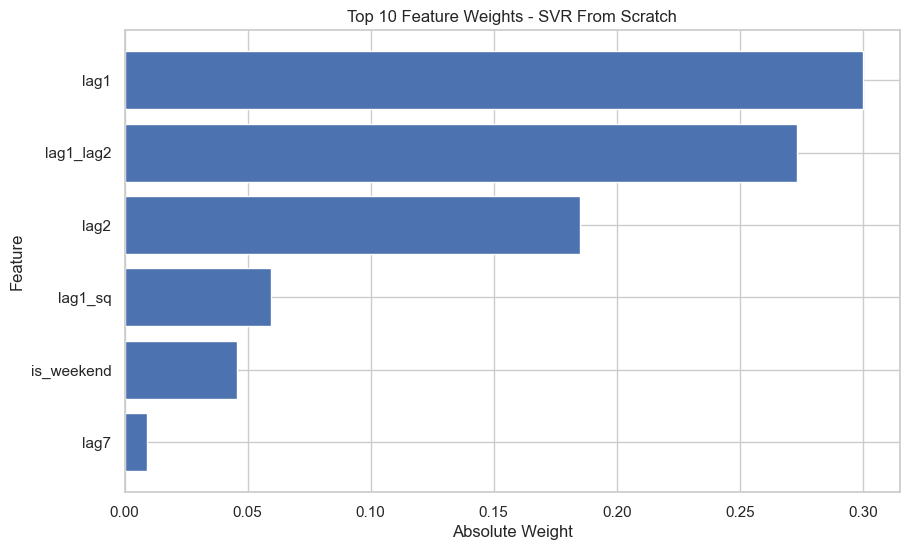


TOP 10 FEATURE WEIGHTS
      Feature    Weight
0        lag1  0.299920
5   lag1_lag2 -0.273328
1        lag2  0.185116
4     lag1_sq -0.059728
3  is_weekend  0.045800
2        lag7  0.008972


In [132]:
# =========================================================
# BẢNG SO SÁNH DỰ ĐOÁN
# =========================================================

comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_test_pred_svr,
    "Error": y_test - y_test_pred_svr,
    "Abs_Error": np.abs(y_test - y_test_pred_svr)
})

print("=" * 60)
print("10 DÒNG DỰ ĐOÁN ĐẦU TIÊN TRÊN TEST SET")
print("=" * 60)
print(comparison_df.head(10))

print("\n" + "=" * 60)
print("THỐNG KÊ SAI SỐ TRÊN TEST SET")
print("=" * 60)
print(comparison_df[["Error", "Abs_Error"]].describe())


# =========================================================
# TOP FEATURE WEIGHTS
# Giữ lại ở mức vừa phải để giải thích feature nào ảnh hưởng mạnh hơn
# =========================================================
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Weight": svr_model.weights
})

feature_importance["Abs_Weight"] = np.abs(feature_importance["Weight"])
feature_importance = feature_importance.sort_values("Abs_Weight", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"].head(10), feature_importance["Abs_Weight"].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Weights - SVR From Scratch")
plt.xlabel("Absolute Weight")
plt.ylabel("Feature")
plt.grid(True, axis="x")
plt.show()

print("\n" + "=" * 60)
print("TOP 10 FEATURE WEIGHTS")
print("=" * 60)
print(feature_importance[["Feature", "Weight"]].head(10))

### Đánh giá trực quan mức độ sai lệch của SVR

Tương tự như Linear Regression, biểu đồ dưới đây phân loại các dự đoán của SVR thành 3 mức độ sai lệch: Tốt (xanh), Trung bình (vàng) và Lớn (đỏ). Điều này giúp chúng ta nhìn rõ ràng xem SVR dự đoán tốt/kém ở khoảng giá trị doanh thu nào.

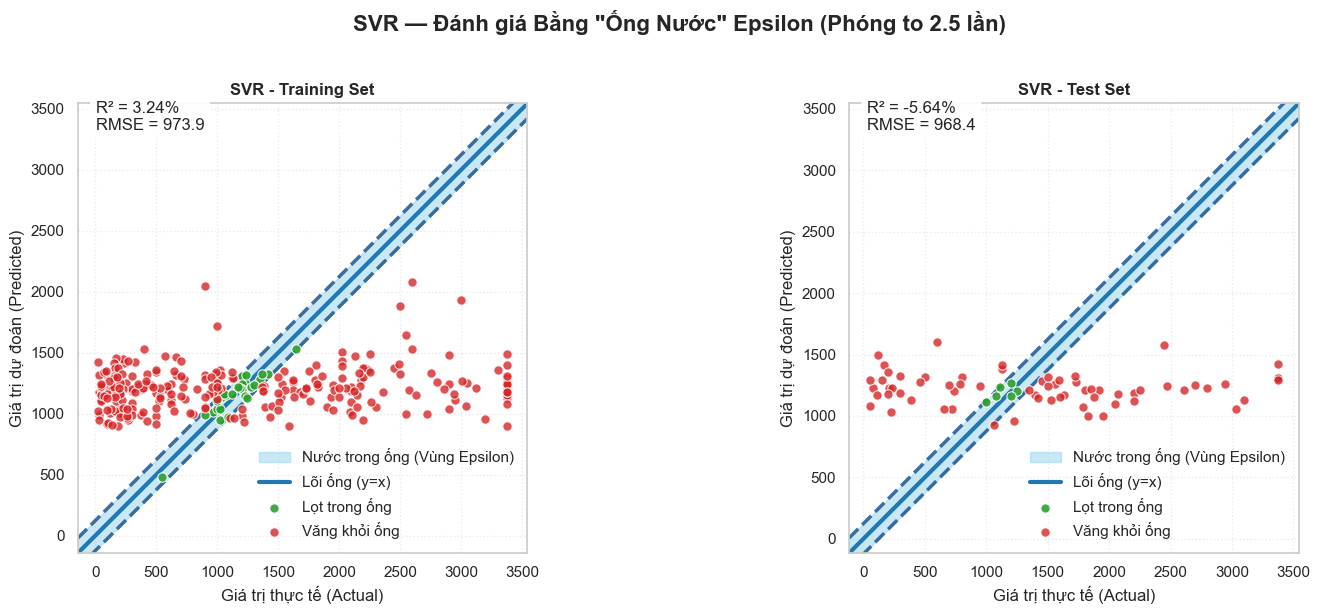

In [133]:
# =========================================
# VISUALIZE SVR ĐÁNH GIÁ VỚI "ỐNG NƯỚC EPSILON"
# =========================================
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lấy giá trị epsilon đã quy đổi về scale thật từ mô hình SVR
epsilon_original = svr_model.epsilon * svr_model.y_std_

# Tăng visual_multiplier để tạo hiệu ứng ống nước to và rõ hơn
visual_multiplier = 2.5 
display_epsilon = epsilon_original * visual_multiplier

for ax, y_true, y_pred, title, metrics in [
    (axes[0], y_train, y_train_pred_svr, 'SVR - Training Set', train_metrics_svr),
    (axes[1], y_test,  y_test_pred_svr,  'SVR - Test Set',     test_metrics_svr),
]:

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    # Thêm padding để đồ thị thoáng hơn
    padding = (hi - lo) * 0.05
    ideal_line = np.linspace(lo - padding, hi + padding, 100)

    # Tính sai số tuyệt đối
    err = np.abs(y_true - y_pred)

    # Phân loại điểm
    inside_tube = err <= display_epsilon
    outside_tube = err > display_epsilon

    # 1. Vẽ "dòng nước" bên trong (Nền xanh nhạt đậm hơn chút)
    ax.fill_between(
        ideal_line,
        ideal_line - display_epsilon,
        ideal_line + display_epsilon,
        color="#87CEEB", alpha=0.45, label='Nước trong ống (Vùng Epsilon)'
    )

    # 2. Vẽ "thành ống nước" (Viền màu xanh dương đậm, nét đứt dày)
    ax.plot(ideal_line, ideal_line + display_epsilon, linestyle="--", color="#104E8B", linewidth=2.5, alpha=0.8)
    ax.plot(ideal_line, ideal_line - display_epsilon, linestyle="--", color="#104E8B", linewidth=2.5, alpha=0.8)

    # 3. Lõi ống nước (Đường y=x trung tâm nét liền dày)
    ax.plot(ideal_line, ideal_line, '-', color="#1f77b4", lw=3, label='Lõi ống (y=x)')

    # 4. Vẽ các chấm dữ liệu (Chấm to hơn, có viền trắng để nổi lên khỏi nước)
    ax.scatter(y_true[inside_tube], y_pred[inside_tube],
               color='#2ca02c', alpha=0.9, s=45, edgecolors='white', linewidth=0.8,
               label='Lọt trong ống', zorder=3)

    ax.scatter(y_true[outside_tube], y_pred[outside_tube],
               color='#d62728', alpha=0.8, s=45, edgecolors='white', linewidth=0.8,
               label='Văng khỏi ống', zorder=3)

    ax.set_xlim(lo - padding, hi + padding)
    ax.set_ylim(lo - padding, hi + padding)
    ax.set_aspect('equal')

    # Hiển thị metrics R2 và RMSE
    ax.text(0.04, 0.94,
            f"R² = {metrics['R2']*100:.2f}%\nRMSE = {metrics['RMSE']:.1f}",
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    ax.set_xlabel('Giá trị thực tế (Actual)')
    ax.set_ylabel('Giá trị dự đoán (Predicted)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.4, linestyle=':')

plt.suptitle(f'SVR — Đánh giá Bằng "Ống Nước" Epsilon (Phóng to {visual_multiplier} lần)', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [134]:
# =========================================================
# KẾT LUẬN PHẦN SVR
# =========================================================

print("=" * 60)
print("KẾT LUẬN MÔ HÌNH SVR FROM SCRATCH")
print("=" * 60)

print(f"""
1.
   - dùng epsilon-insensitive loss đúng tinh thần SVR
   - scale cả X và y trong quá trình huấn luyện
   - inverse transform khi predict để output quay về đơn vị doanh thu thật
2. Vẫn chưa đủ mạnh để dự báo doanh thu chính xác cho vận hành thực tế.
3. Mô hình phù hợp cho:
   - minh họa thuật toán SVR from scratch
   - phân tích học thuật
   - dự báo tham khảo ở mức cơ bản
6. Mô hình chưa phù hợp cho:
   - ra quyết định nhập hàng
   - lập ngân sách doanh thu chính xác
   - tối ưu tồn kho / tài chính
""")

KẾT LUẬN MÔ HÌNH SVR FROM SCRATCH

1.
   - dùng epsilon-insensitive loss đúng tinh thần SVR
   - scale cả X và y trong quá trình huấn luyện
   - inverse transform khi predict để output quay về đơn vị doanh thu thật
2. Vẫn chưa đủ mạnh để dự báo doanh thu chính xác cho vận hành thực tế.
3. Mô hình phù hợp cho:
   - minh họa thuật toán SVR from scratch
   - phân tích học thuật
   - dự báo tham khảo ở mức cơ bản
6. Mô hình chưa phù hợp cho:
   - ra quyết định nhập hàng
   - lập ngân sách doanh thu chính xác
   - tối ưu tồn kho / tài chính



# 12. KẾT LUẬN TỔNG THỂ — Phù hợp ra quyết định doanh số?

## 12.1 Kết luận thực tế từ mô hình SVR from scratch

Mô hình SVR:
- Sai số vẫn còn lớn và hệ số R² trên test vẫn nhỏ hơn 0.

## 12.2 Có đủ để dự đoán doanh thu cửa hàng không?

**Chưa đủ nếu mục tiêu là dự báo chính xác để ra quyết định kinh doanh.**

Mô hình hiện tại chỉ phù hợp để:
- minh họa cách hoạt động của SVR from scratch
- phân tích xu hướng ở mức tham khảo
- phục vụ bài tập / thuyết trình

Mô hình chưa đủ mạnh để:
- dự báo doanh thu chính xác theo ngày
- quyết định nhập hàng / tồn kho / tài chính

## 12.3 Hướng cải tiến

Để mô hình đủ tốt hơn, cần:
1. Thêm nhiều đặc trưng mạnh hơn
2. Xử lý outlier hoặc log-transform target
3. Tối ưu tham số kỹ hơn
4. So sánh với mô hình mạnh hơn như tree boosting